
=== NOT Gate using Single Layer Perceptron ===
Weights: [[-0.1]]
Bias: [0.1]

Predictions: [1 0]

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



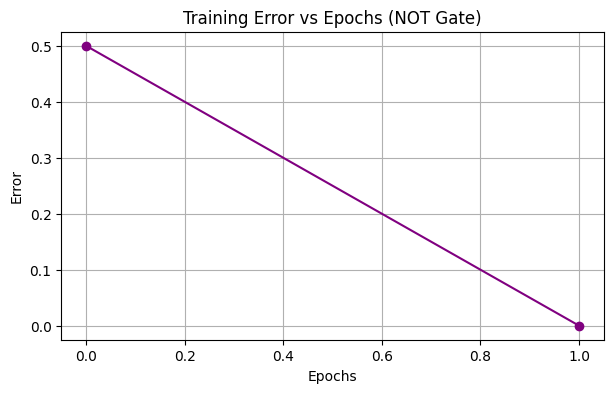

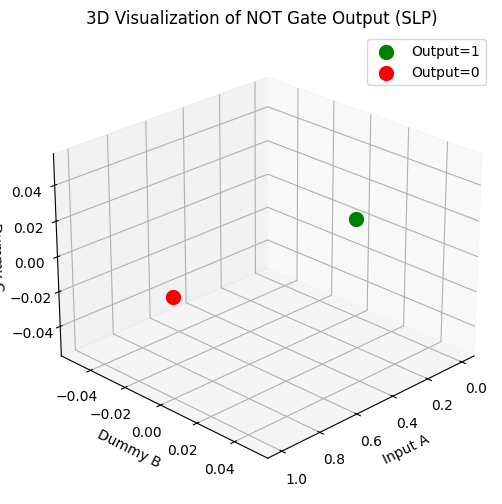

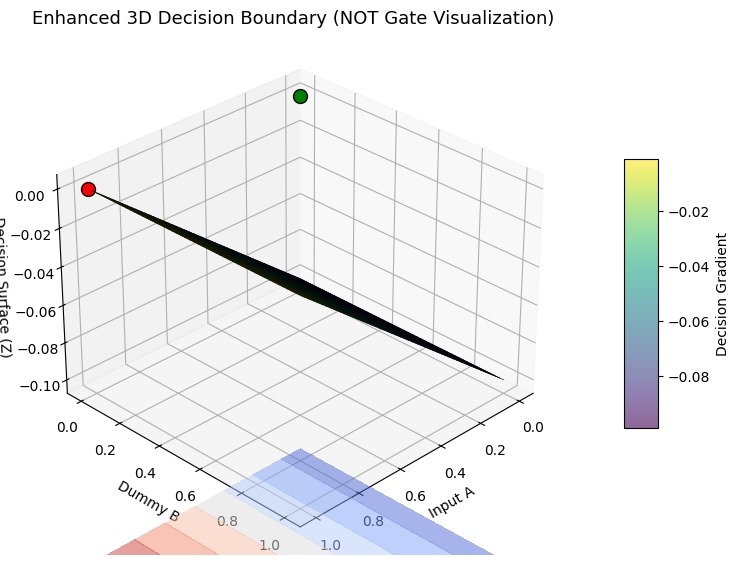

In [1]:
# not_gate_slp.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# 1. Define the dataset (NOT gate)
# ----------------------------
# Input (A)
X = np.array([[0], [1]])

# Output (NOT A)
y = np.array([1, 0])

# ----------------------------
# 2. Create and train the SLP model
# ----------------------------
model = Perceptron(max_iter=100, eta0=0.1, random_state=42)
errors = []

# Manual training loop to track error per epoch
for _ in range(100):
    model.partial_fit(X, y, classes=np.unique(y))
    y_pred = model.predict(X)
    err = np.mean(y_pred != y)
    errors.append(err)
    if err == 0:
        break

# ----------------------------
# 3. Predictions and metrics
# ----------------------------
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
report = classification_report(y, y_pred)

# ----------------------------
# 4. Display results
# ----------------------------
print("\n=== NOT Gate using Single Layer Perceptron ===")
print("Weights:", model.coef_)
print("Bias:", model.intercept_)
print("\nPredictions:", y_pred)
print("\nAccuracy:", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# ----------------------------
# 5. Plot line chart (Error vs Epochs)
# ----------------------------
plt.figure(figsize=(7, 4))
plt.plot(errors, marker='o', color='purple')
plt.title("Training Error vs Epochs (NOT Gate)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# ----------------------------
# 6. 3D Visualization (for conceptual visualization)
# ----------------------------
# Since NOT gate is 1D, we'll visualize it in 3D for consistency
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Create dummy dimensions (B, C) as zeros for visualization
X3D = np.hstack((X, np.zeros((X.shape[0], 2))))

for xi, yi in zip(X3D, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, label=f'Output={yi}')

ax.set_title("3D Visualization of NOT Gate Output (SLP)")
ax.set_xlabel("Input A")
ax.set_ylabel("Dummy B")
ax.set_zlabel("Dummy C")
ax.view_init(25, 45)

# Avoid duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# ----------------------------
# 7. Enhanced 3D Visualization (Fixed for 1D Input)
# ----------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Create 3D coordinates (A, Dummy B, Dummy C)
X3D = np.hstack((X, np.zeros((X.shape[0], 2))))

# Scatter the input-output points
for xi, yi in zip(X3D, y_pred):
    color = 'green' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], xi[2], c=color, s=100, edgecolor='k', depthshade=True)

# Create high-resolution mesh grid for visualization plane
a_range = np.linspace(0, 1, 50)
b_range = np.linspace(0, 1, 50)
aa, bb = np.meshgrid(a_range, b_range)

# Extract weights and bias
w = model.coef_[0]
b = model.intercept_[0]

# Since NOT gate has only one input weight (w[0]), we build a plane using it
# The decision function is w[0]*A + b = 0  → visualize as Z
zz = -(w[0] * aa + b)

# Ensure zz shape matches aa/bb
zz = zz.reshape(aa.shape)

# Plot the decision surface with gradient shading
surf = ax.plot_surface(aa, bb, zz, cmap='viridis', alpha=0.6, edgecolor='k', linewidth=0.3)

# Add contour projection for clarity
ax.contourf(aa, bb, zz, zdir='z', offset=-0.2, cmap='coolwarm', alpha=0.5)
fig.colorbar(surf, shrink=0.5, aspect=8, pad=0.1, label='Decision Gradient')

ax.set_title("Enhanced 3D Decision Boundary (NOT Gate Visualization)", fontsize=13)
ax.set_xlabel("Input A")
ax.set_ylabel("Dummy B")
ax.set_zlabel("Decision Surface (Z)")
ax.view_init(30, 45)
plt.show()

In [2]:
import joblib
joblib.dump(model, "not_gate_slp.pkl")

['not_gate_slp.pkl']